First few rows of the dataframe:
   Item ID     Status  seqNumber  userId         startDate  \
0        1  Processed        1.0  108799  01-05-2017 00:00   
1        2  Processed        1.0  103690  04-11-2023 00:00   
2        3  Processed        2.0  sdavid  01-01-2016 00:00   
3        4  Processed        1.0  102036  01-05-2017 00:00   
4        5  Processed        1.0  100240  09-03-2021 00:00   

   occupationalLevels workscheduleCode           endDate  contractType  \
0                 NaN             NORM  31-12-9999 00:00           NaN   
1                 NaN              NaN  31-12-9999 00:00           NaN   
2                 NaN             NORM  31-12-9999 00:00           NaN   
3                 NaN             NORM  31-12-9999 00:00           NaN   
4                 NaN             NORM  31-12-9999 00:00           NaN   

      jobCode  ...  customString8  customString7 payScaleGroup  \
0  50070999.0  ...            NaN            NaN           NaN   
1  50000074.0  ..

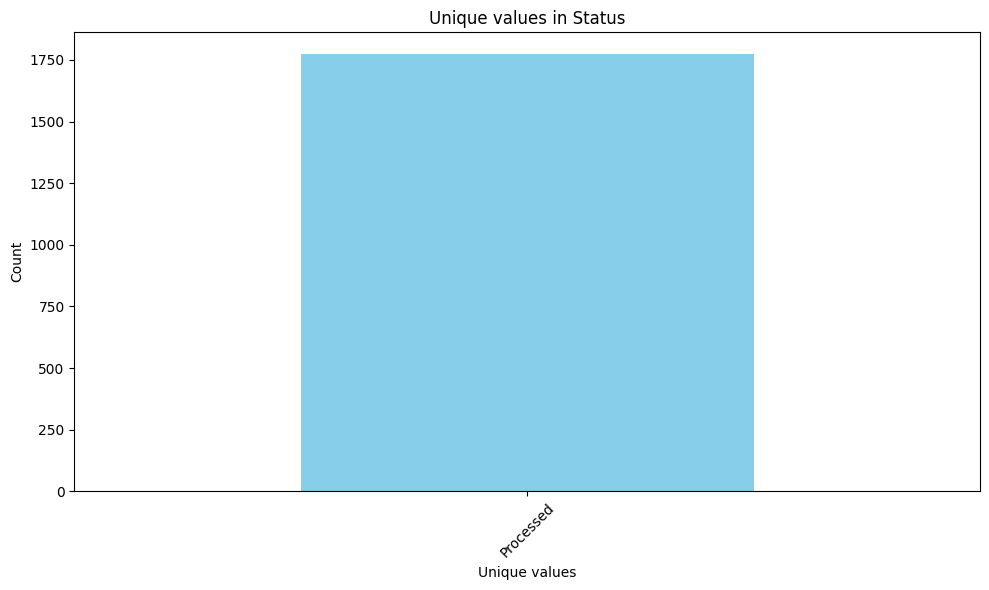

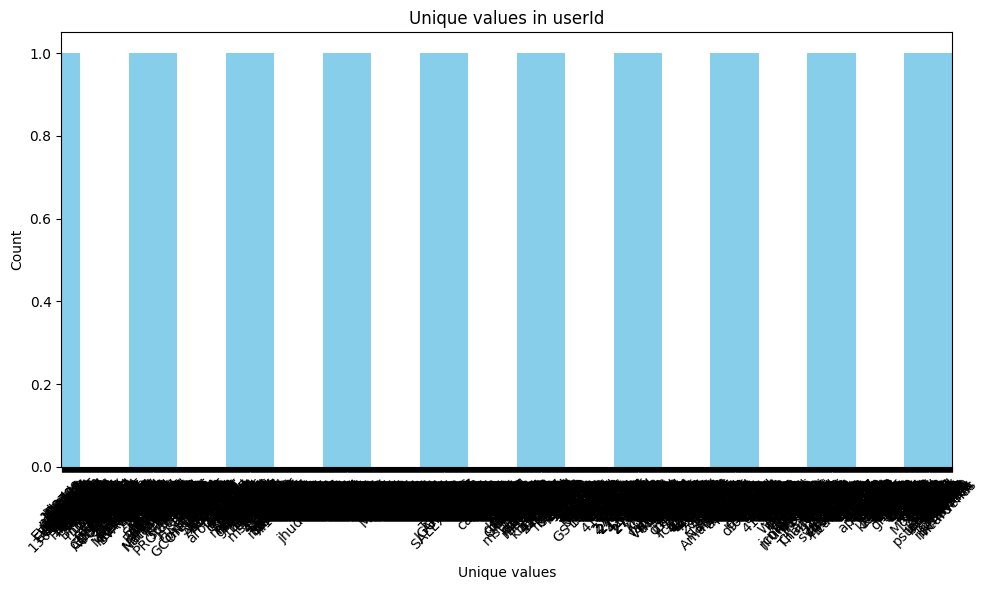

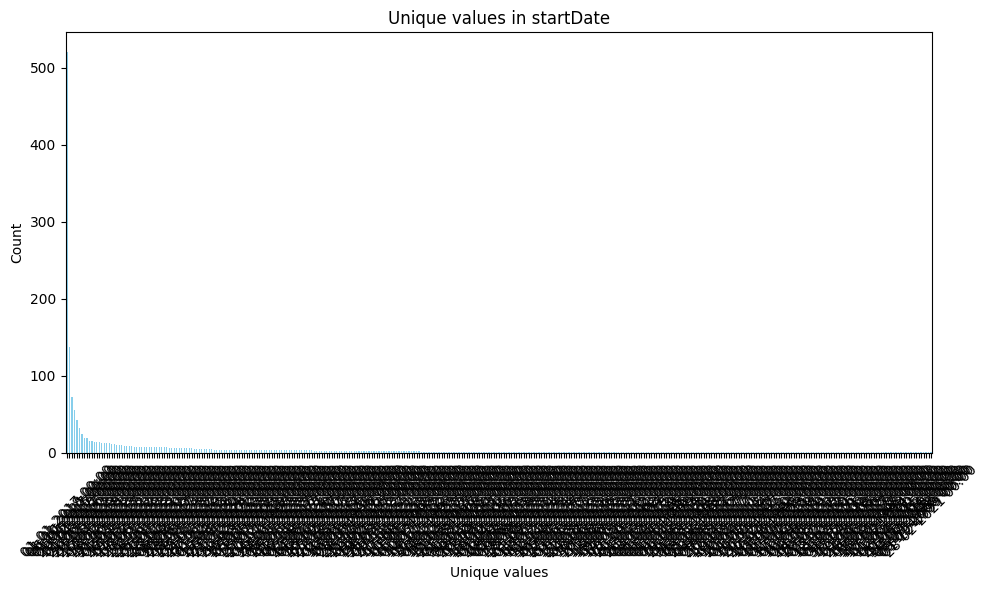

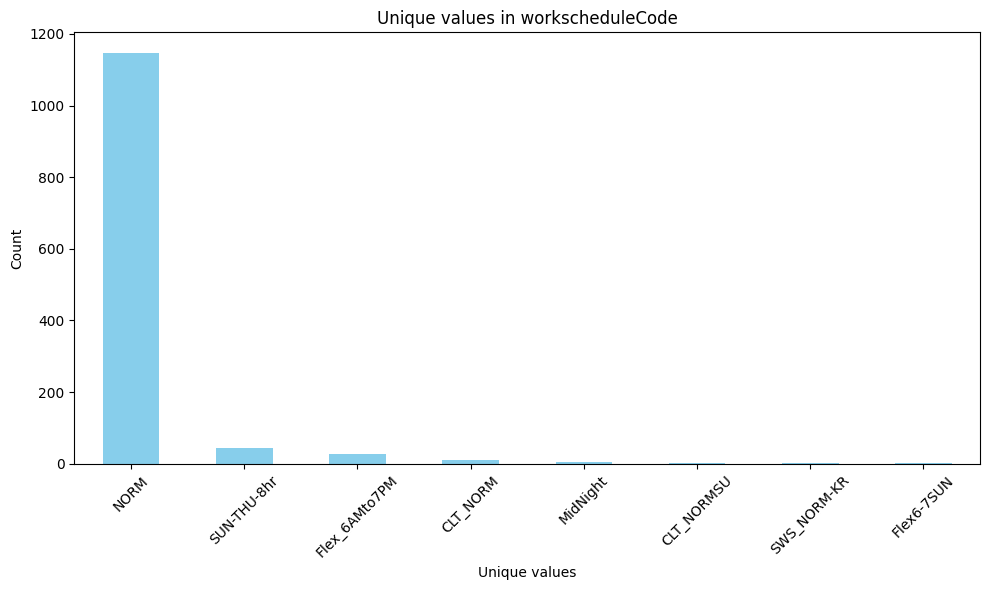

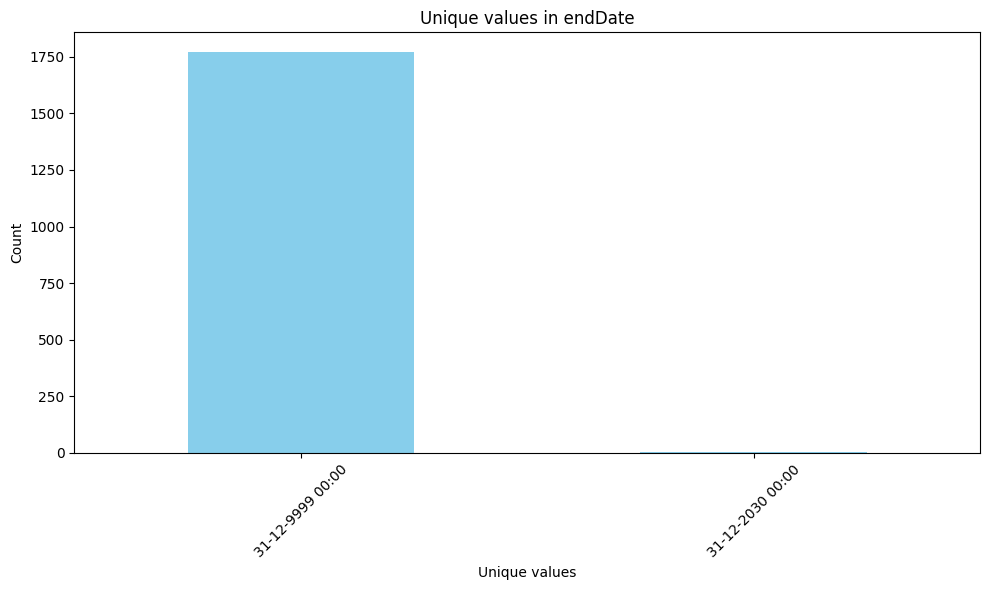

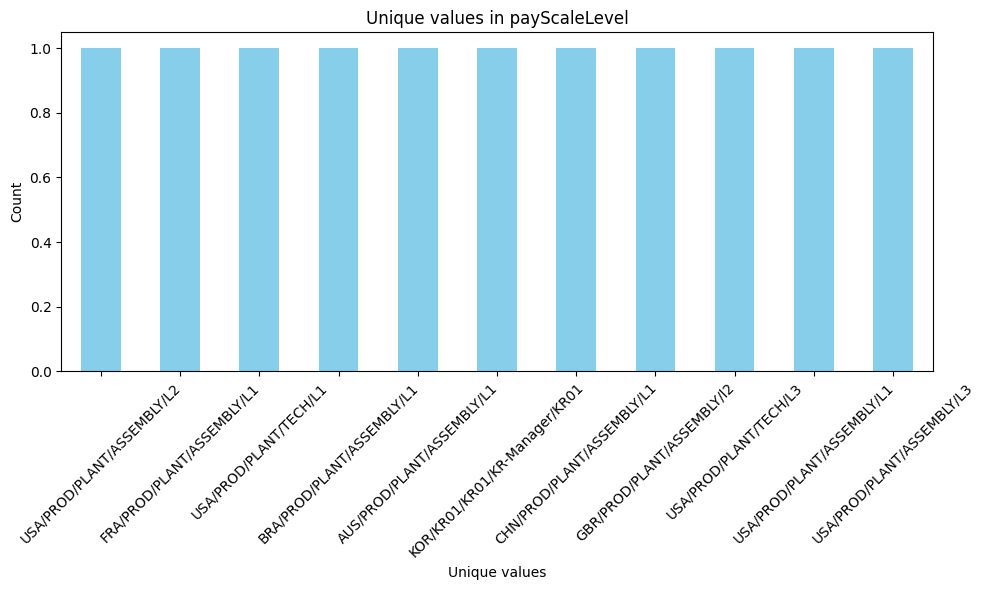

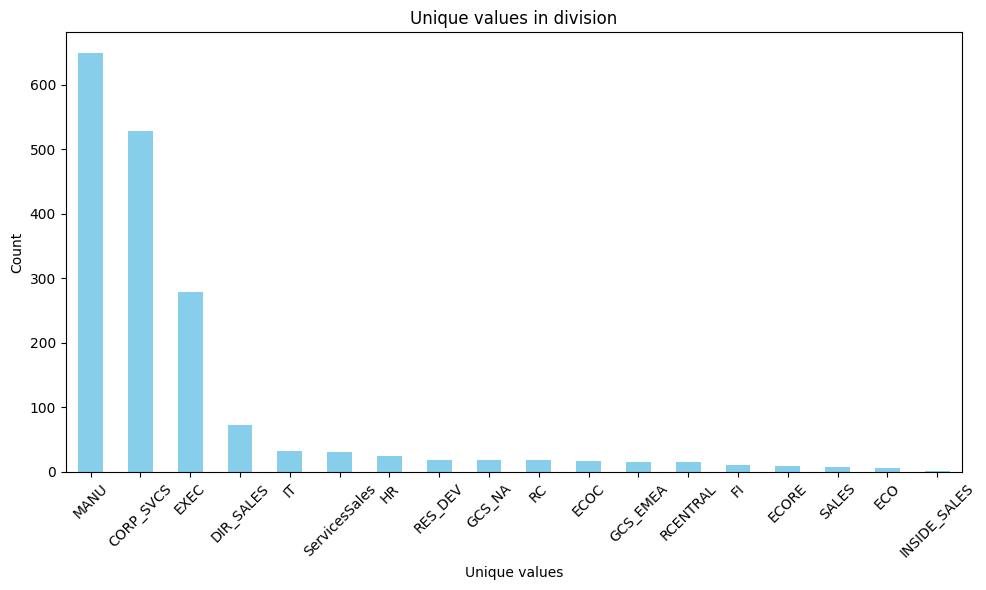

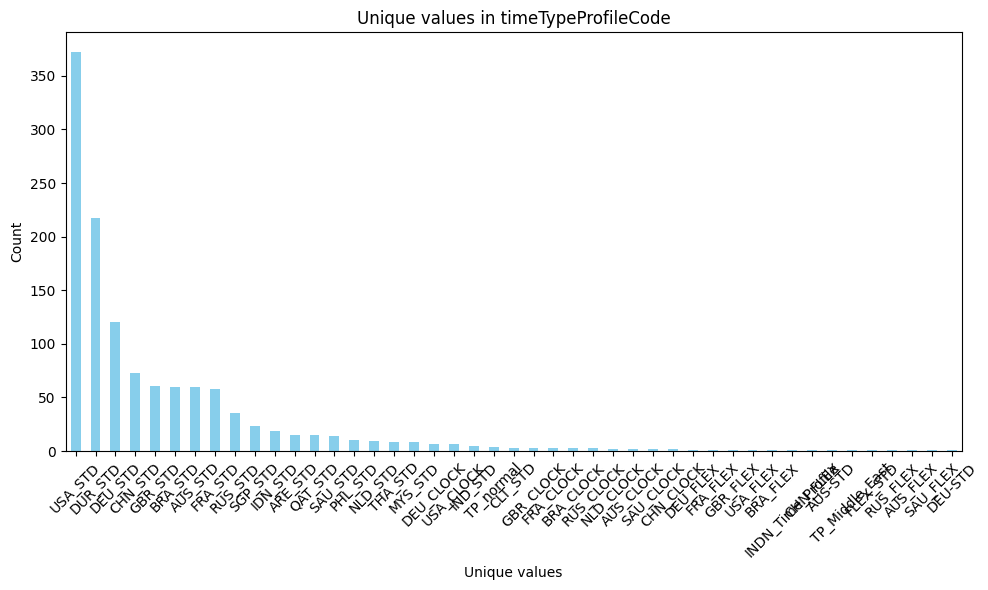

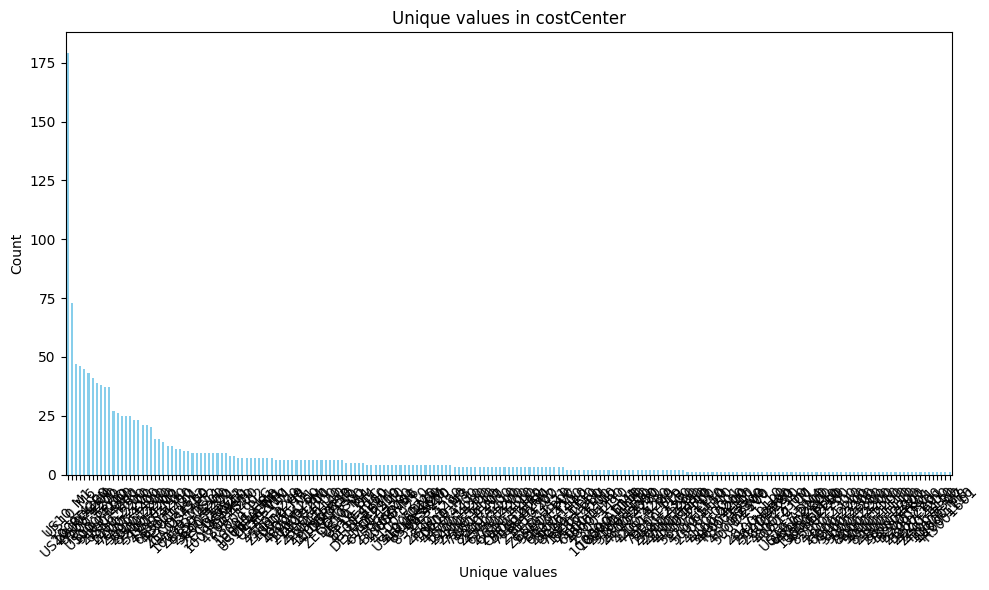

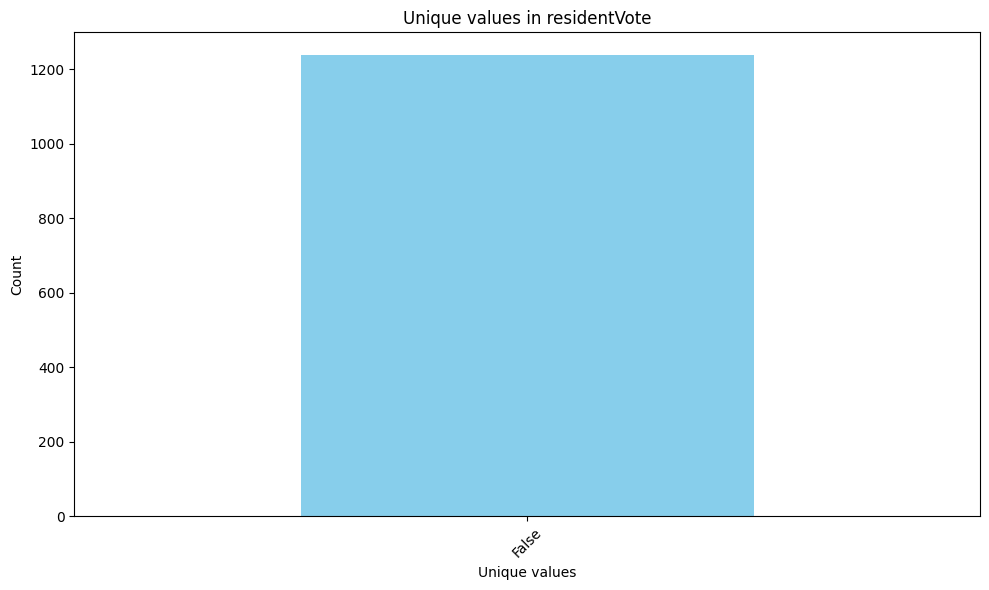

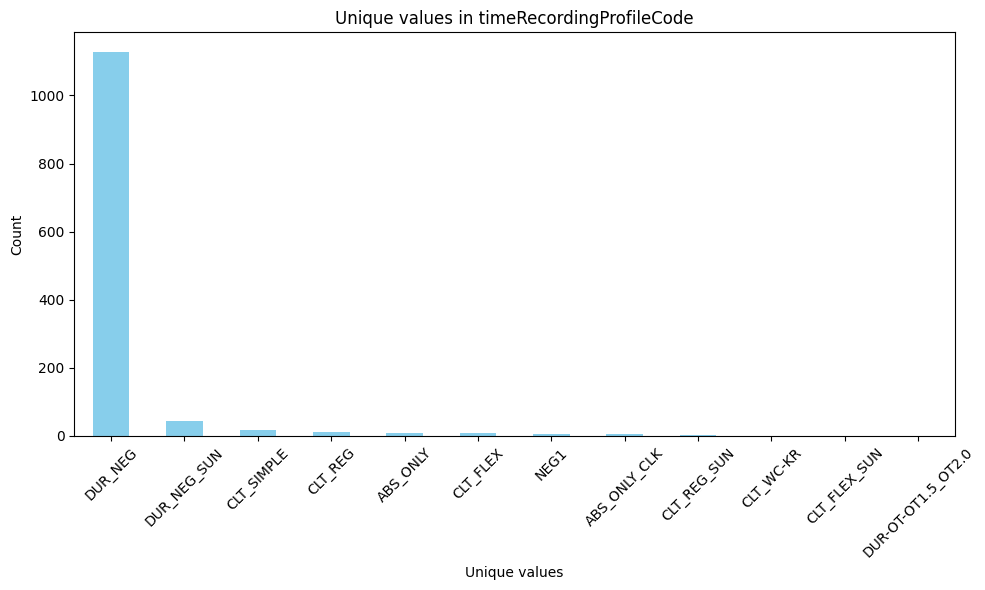

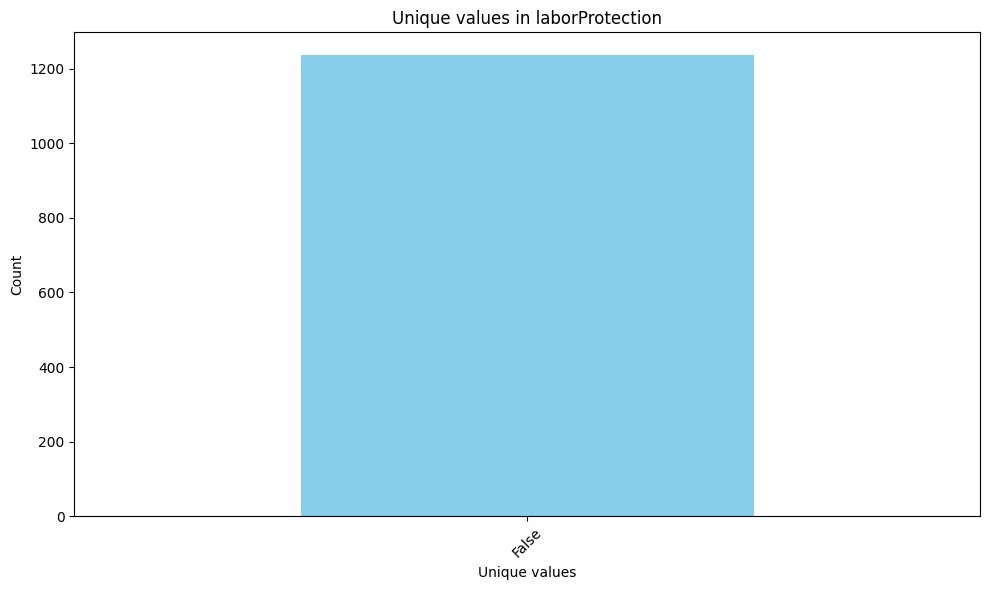

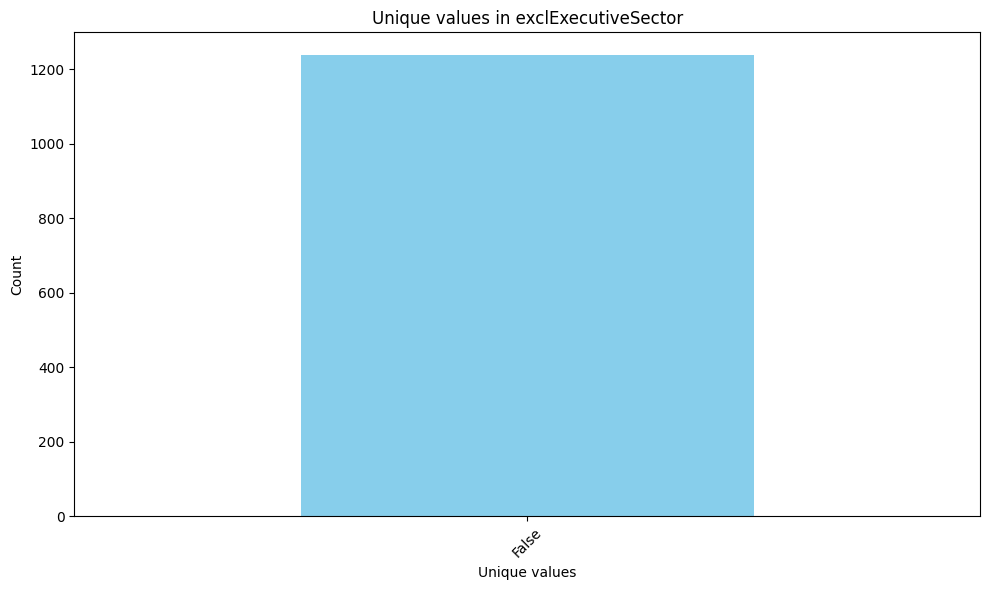

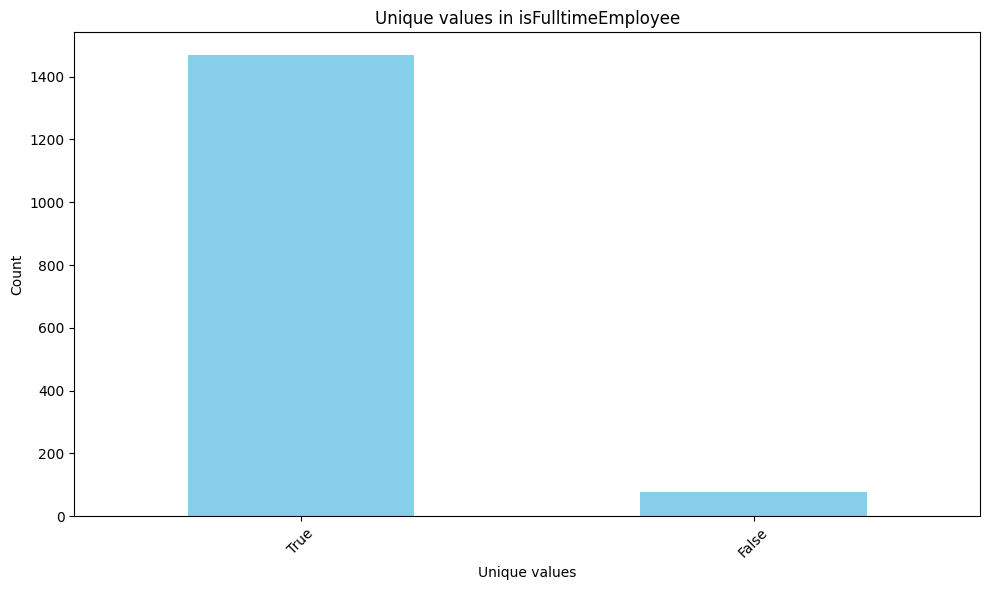

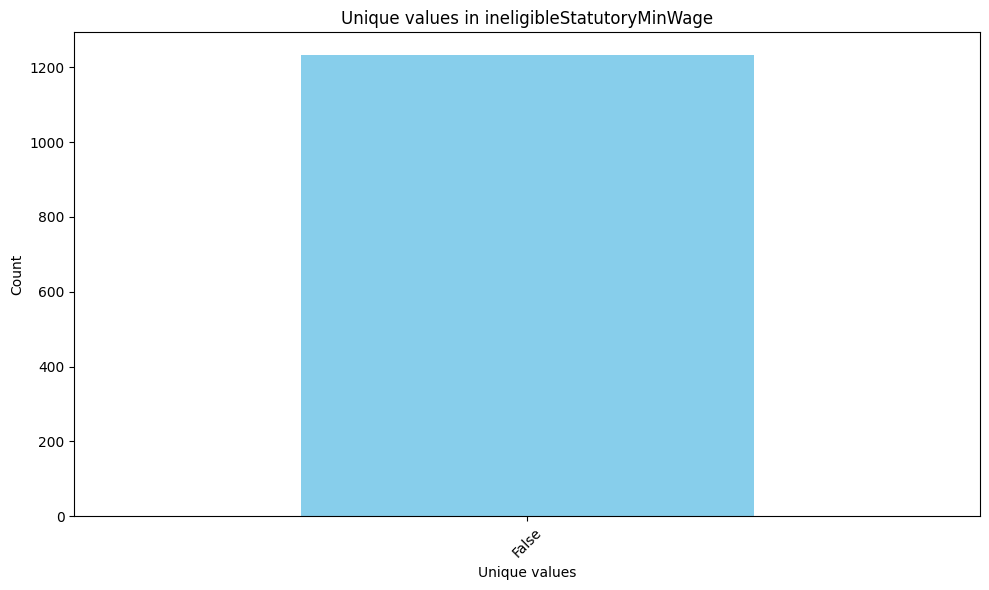

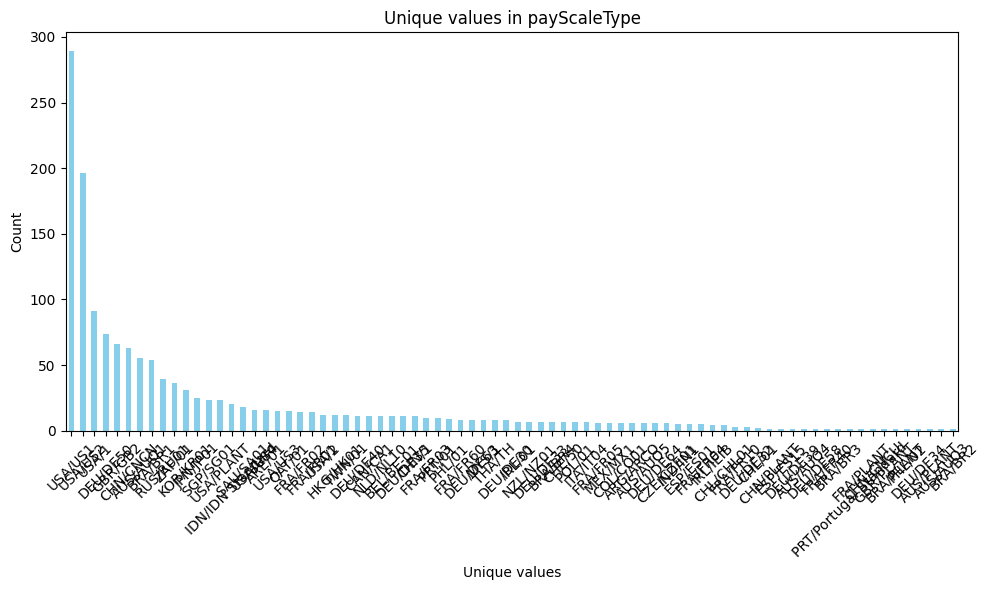

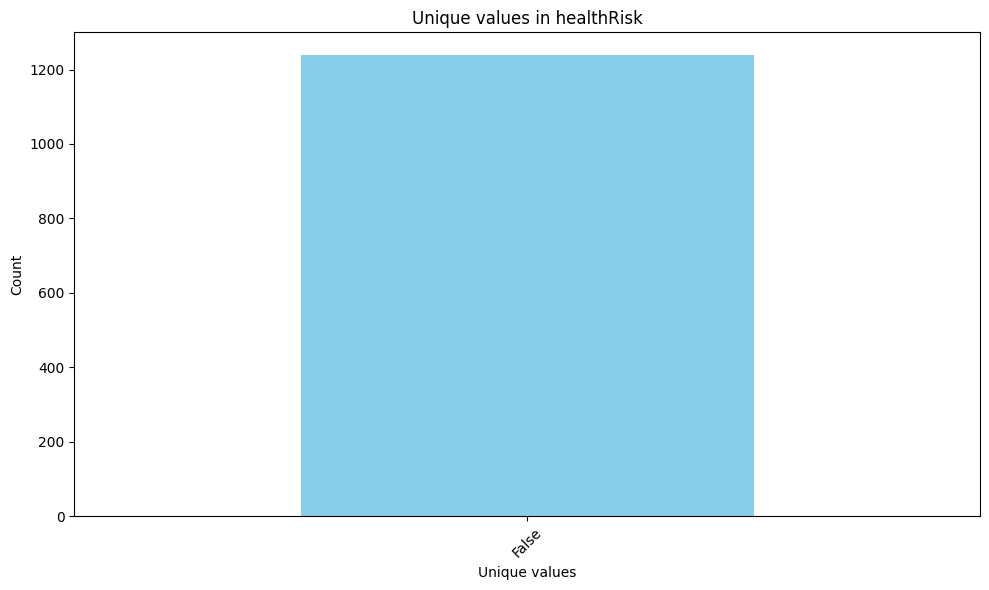

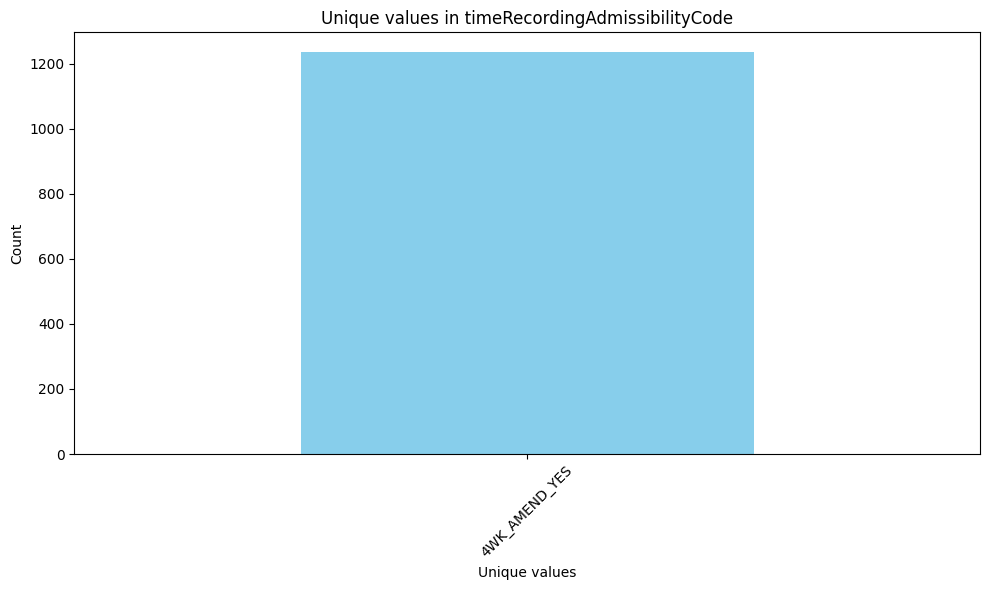

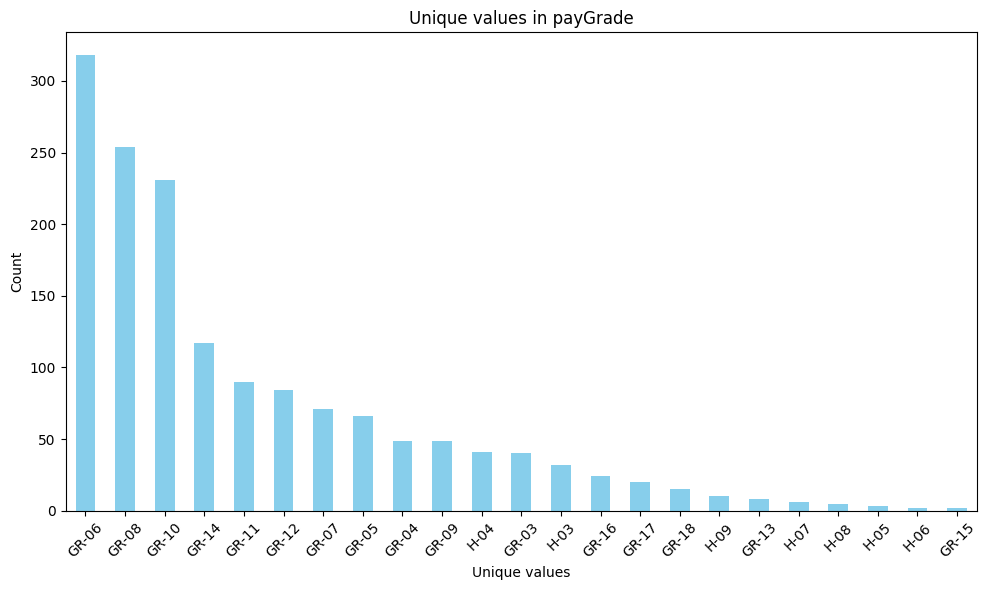

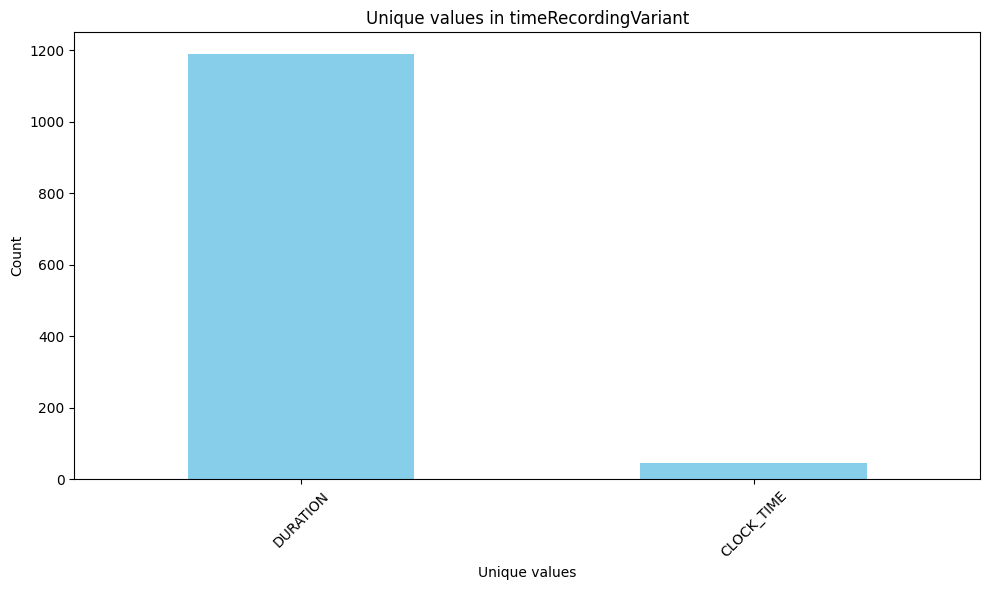

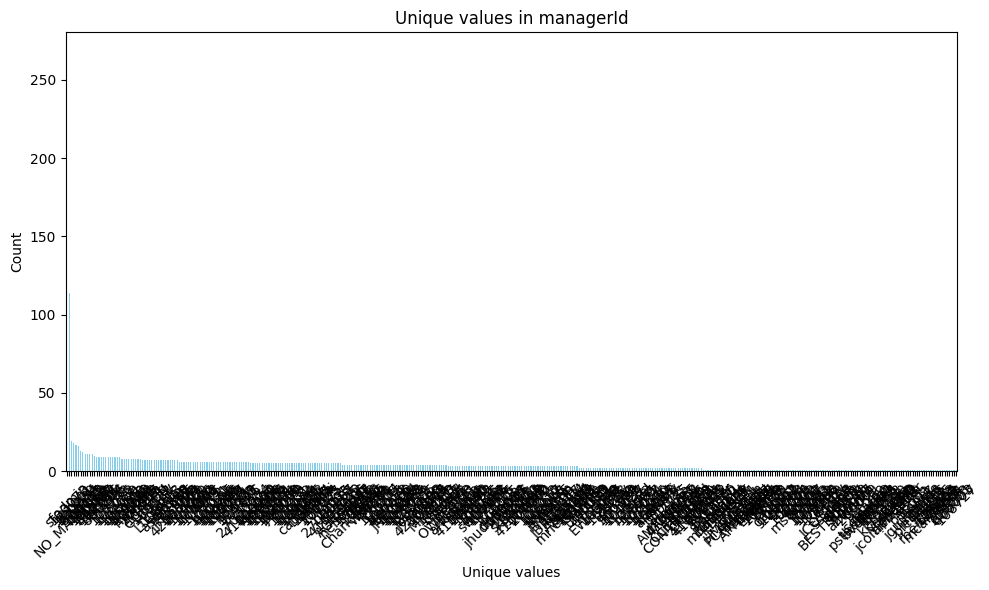

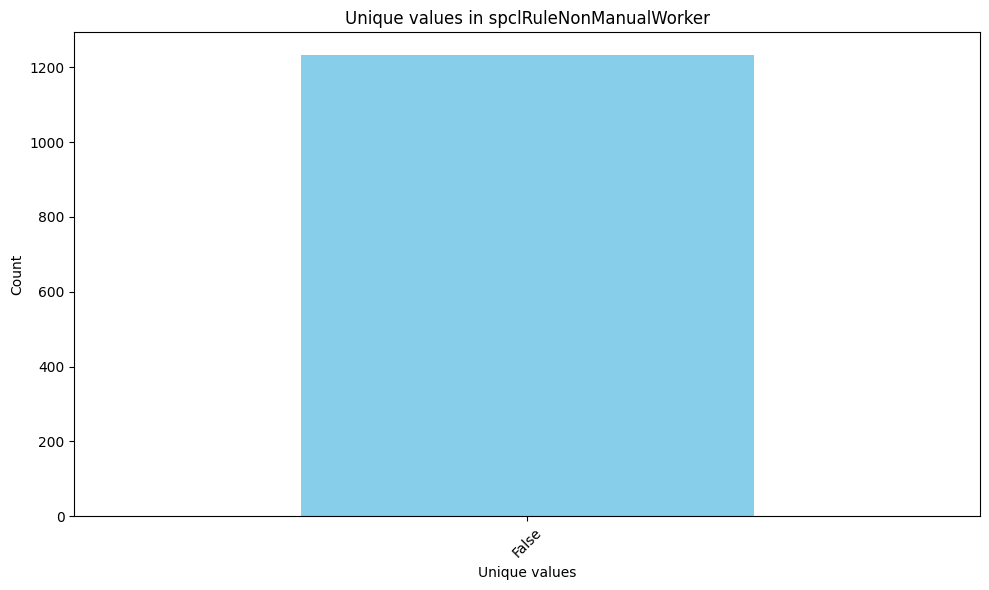

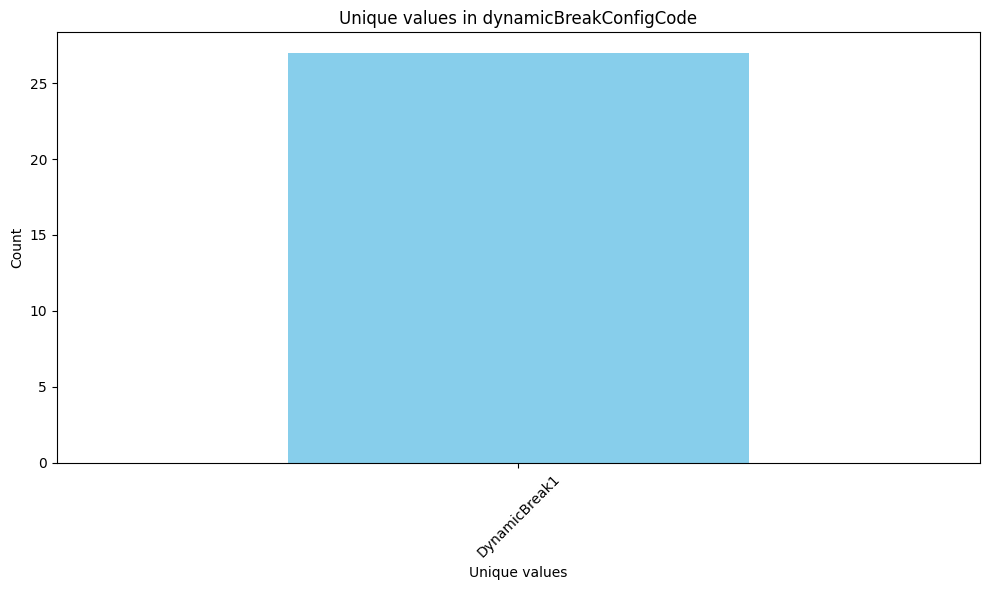

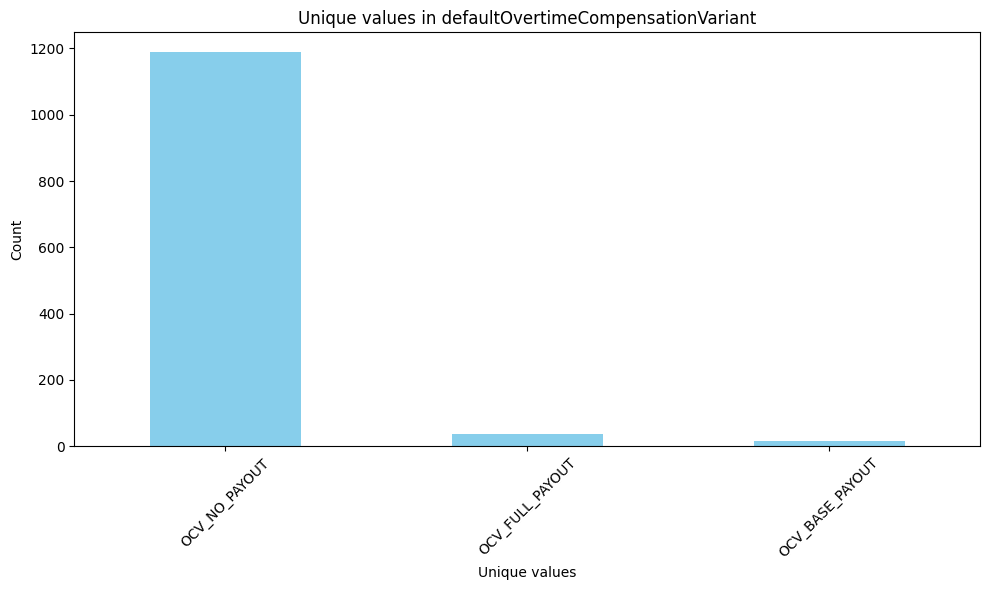

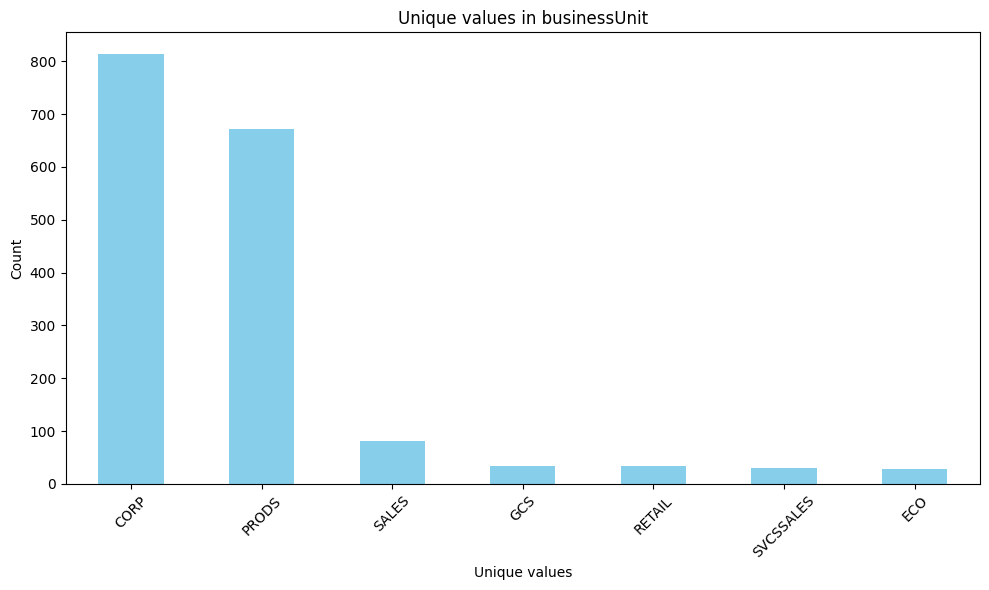

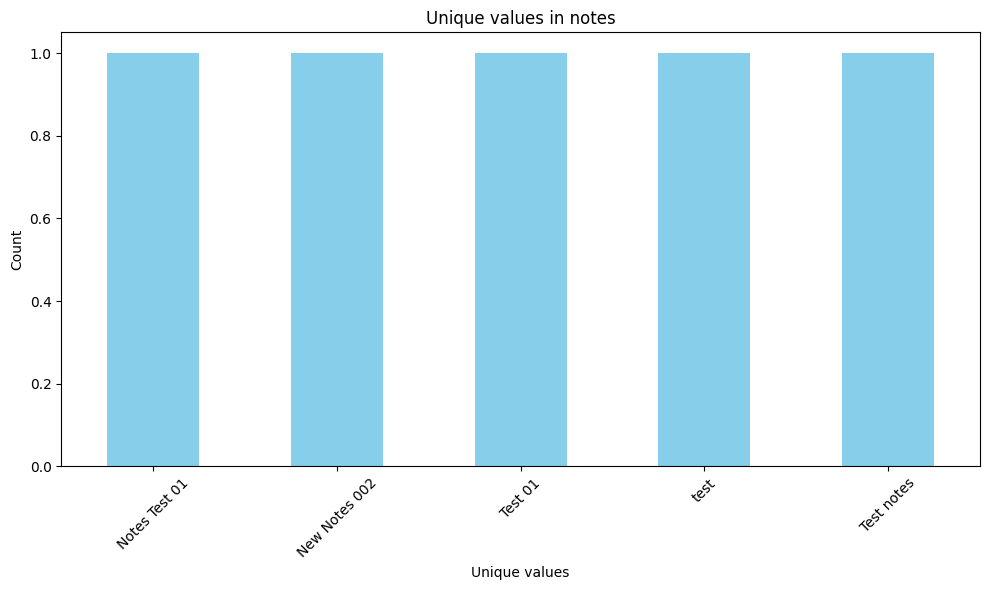

<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 21942 (\N{CJK UNIFIED IDEOGRAPH-55B6}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 26989 (\N{CJK UNIFIED IDEOGRAPH-696D}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 52293 (\N{HANGUL SYLLABLE CAEG}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from current font.
  plt.tight_layout()
<ipython-input-25-be73e6e7359e>:36: Use

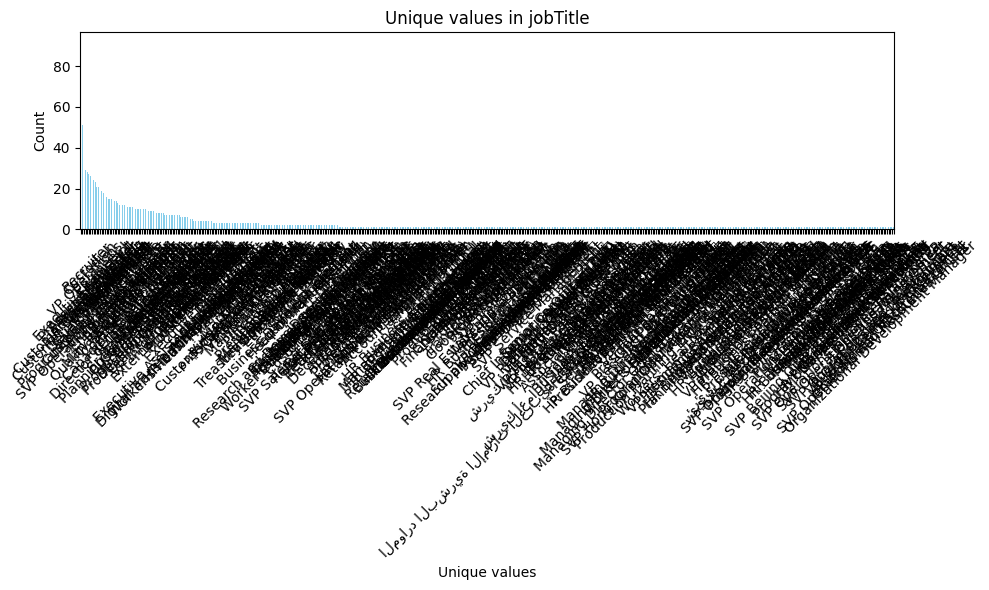

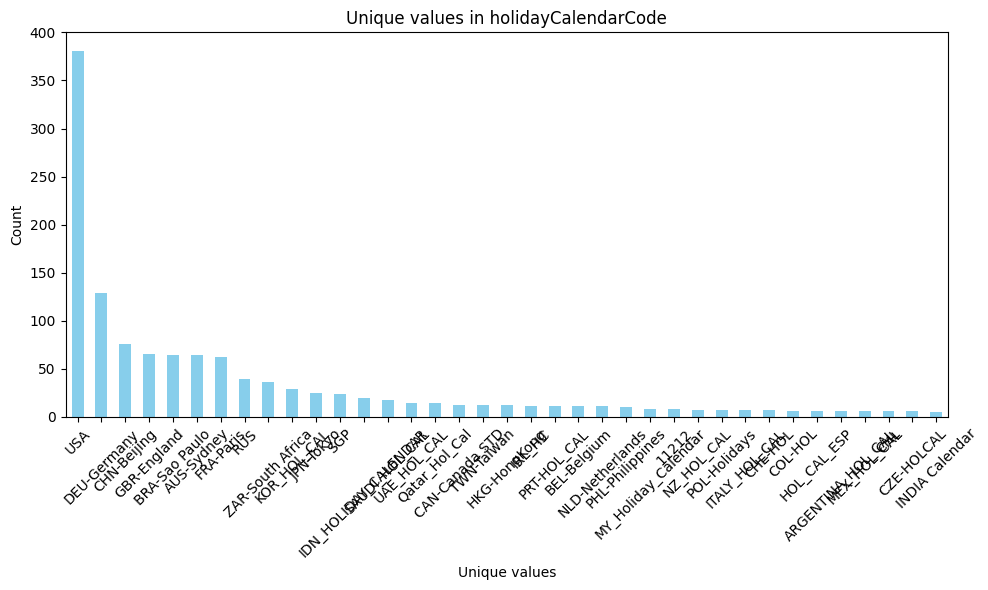

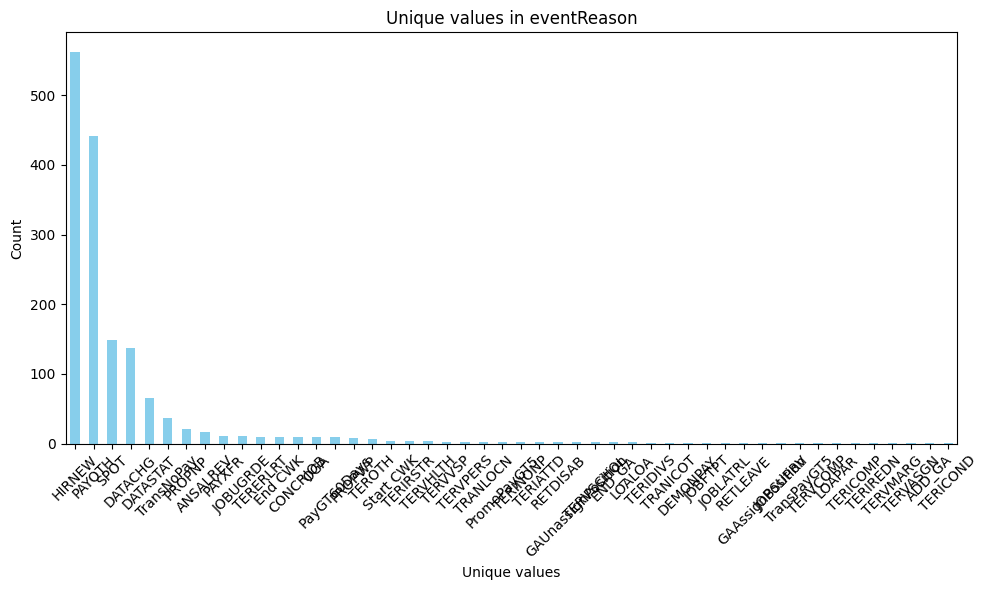

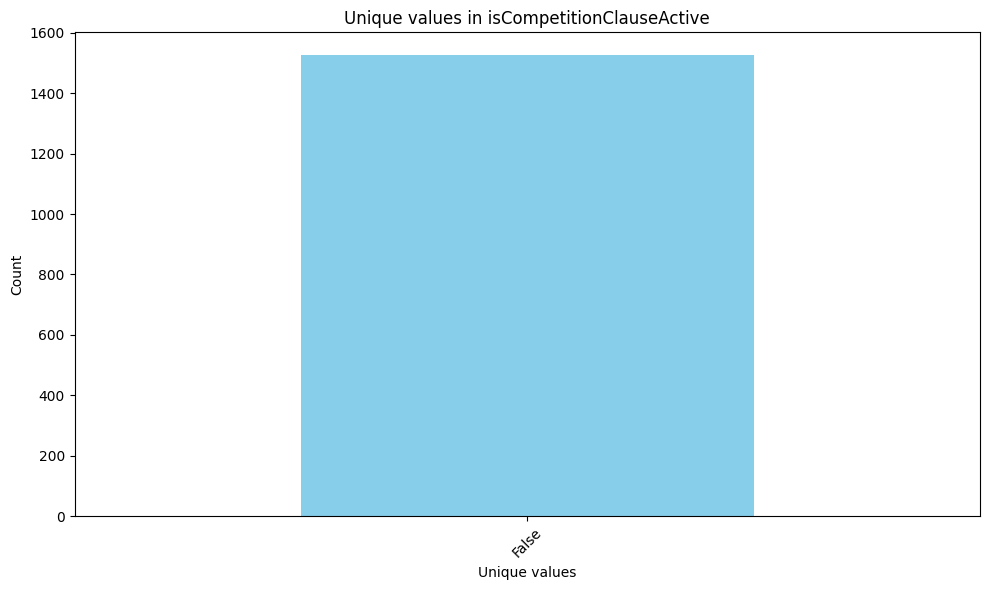

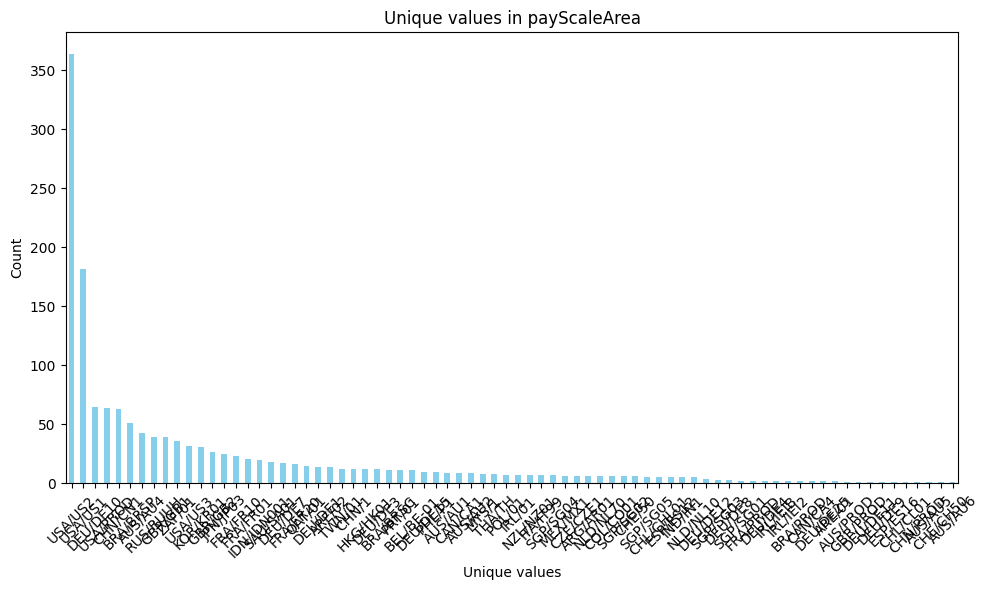

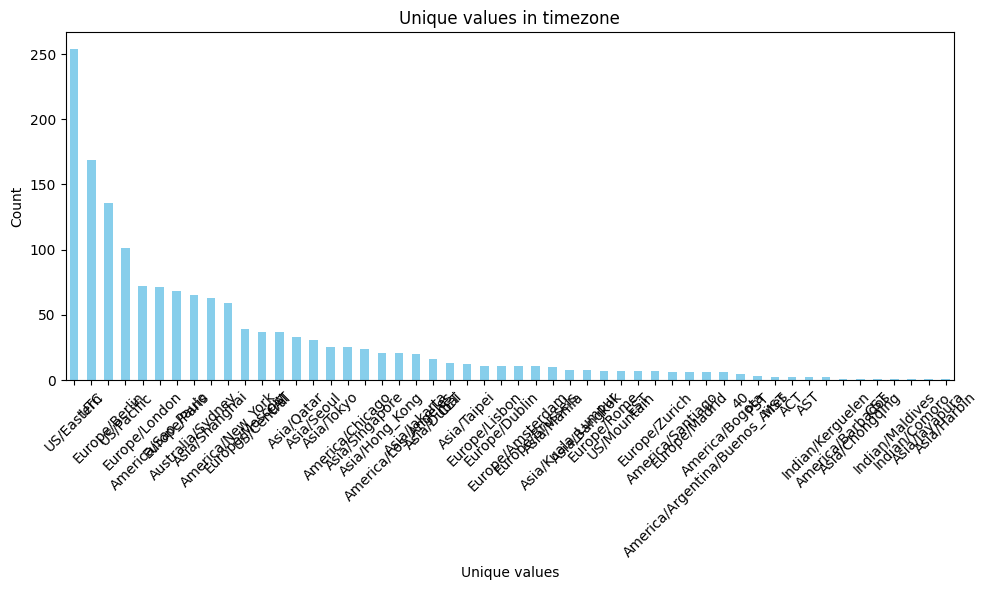

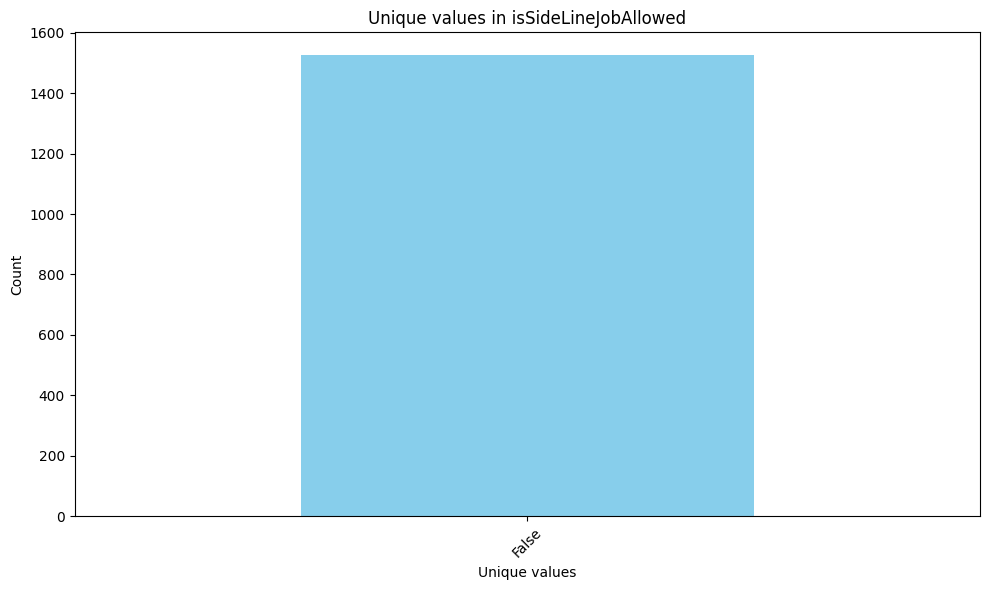

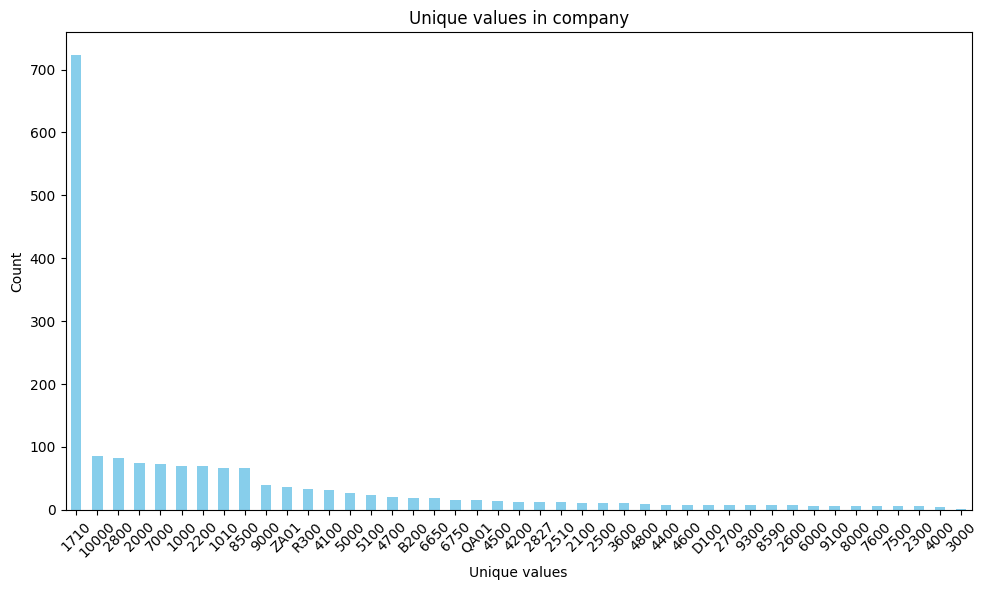

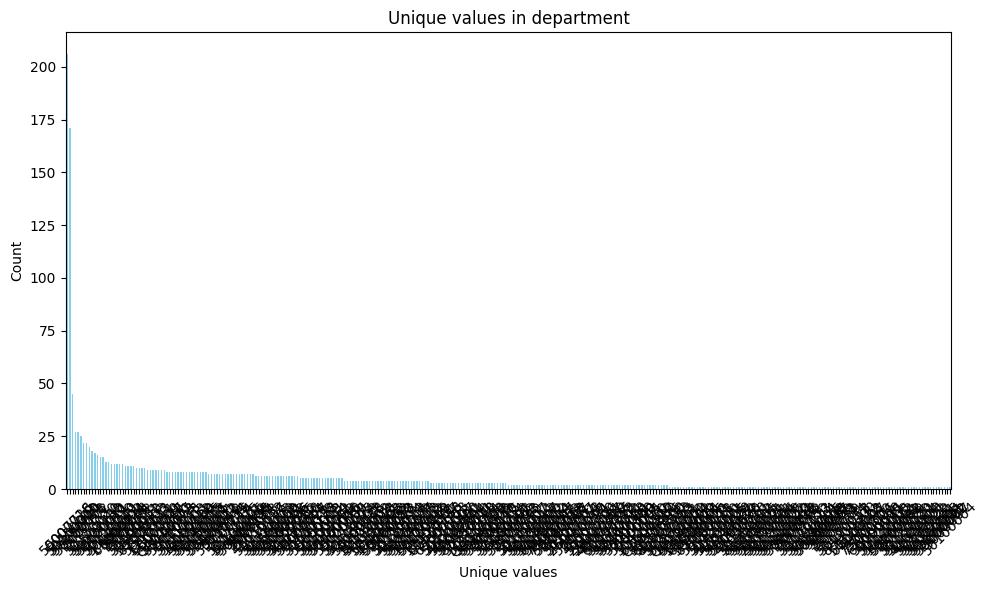

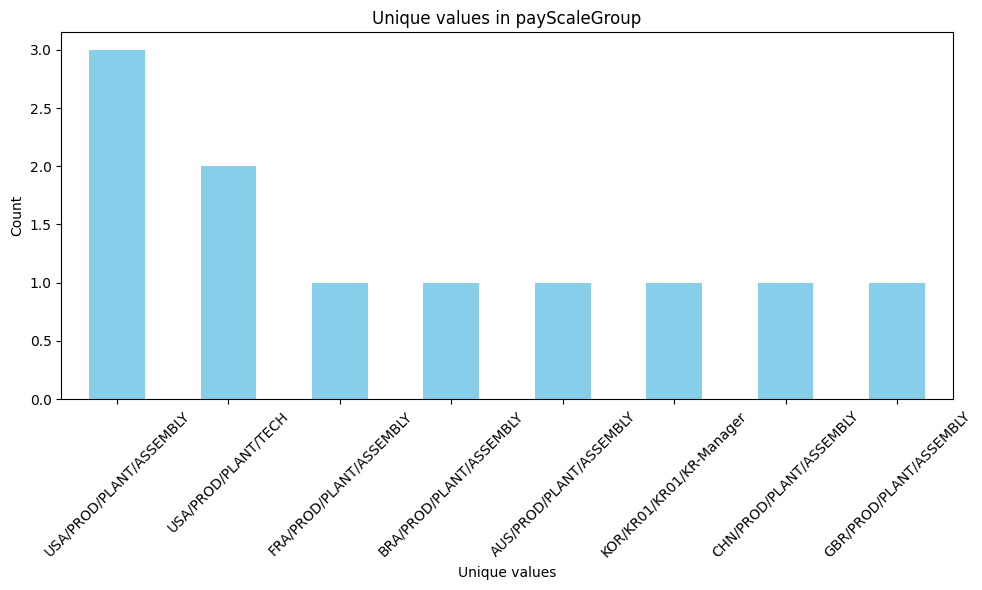

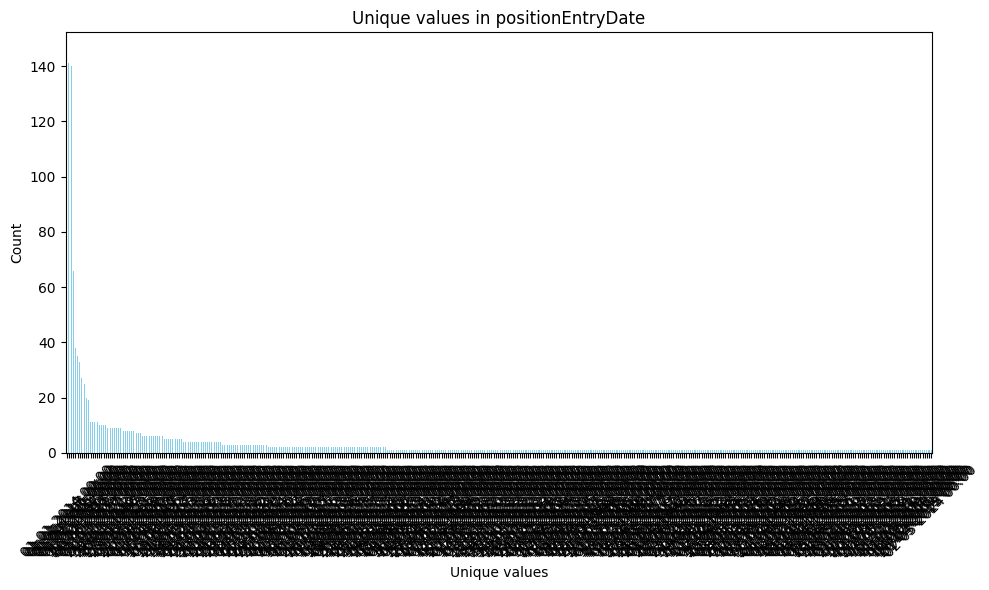

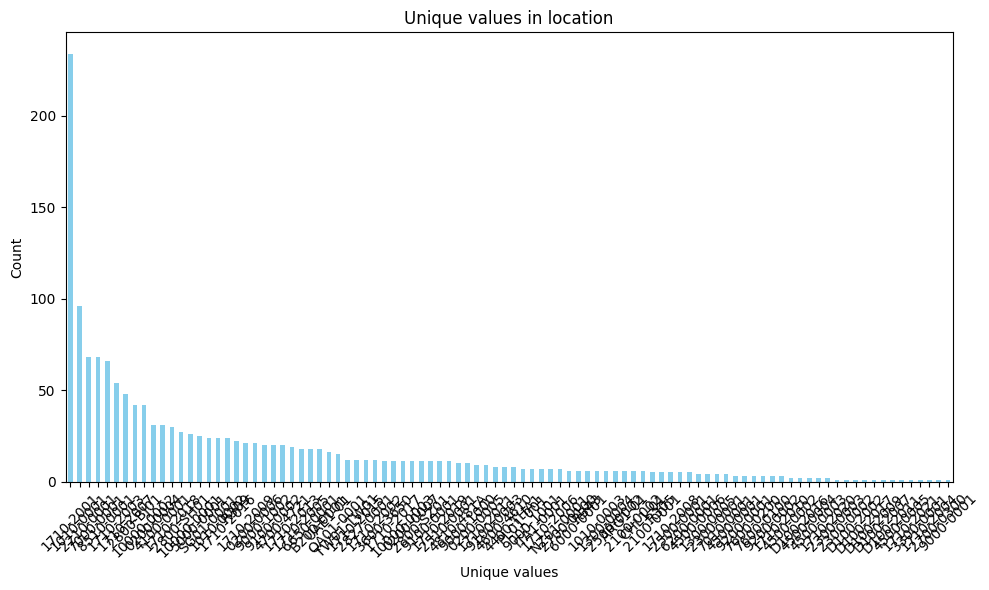

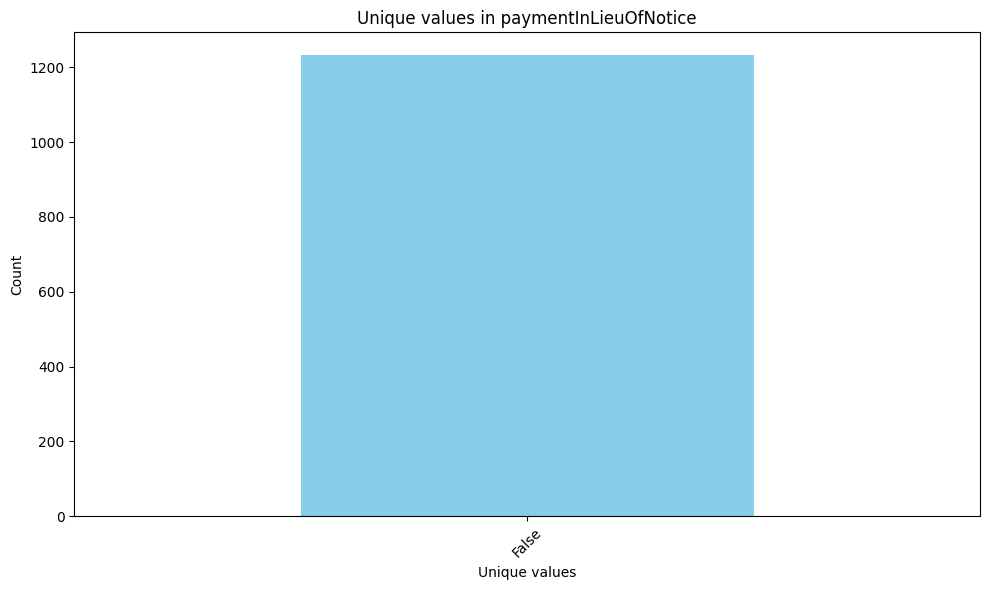

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'jobinfo.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe
print("First few rows of the dataframe:")
print(df.head())

# Display basic statistics
print("\nBasic statistics of the dataframe:")
print(df.describe(include='all'))

# Count the number of null values in each column
null_counts = df.isna().sum()
print("\nNumber of null values in each column:")
print(null_counts)

# Count the number of unique values in each column
unique_counts = df.nunique()
print("\nNumber of unique values in each column:")
print(unique_counts)

# Generate bar graphs for the unique values in each column
for column in df.columns:
    if df[column].dtype == 'object':  # Only plot for categorical data
        unique_value_counts = df[column].value_counts()
        plt.figure(figsize=(10, 6))
        unique_value_counts.plot(kind='bar', color='skyblue')
        plt.title(f'Unique values in {column}')
        plt.xlabel('Unique values')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [ ]:
import pandas as pd

# Load the CSV file
file_path = '/content/jobinfo.csv'
df = pd.read_csv(file_path)

# Define the columns to keep
columns_to_keep = [
    'workingDaysPerWeek', 'standardHours', 'currentWageLevel',
    'jobTitle', 'businessUnit','payGrade'
]

# Drop all columns except the ones to keep
df_filtered = df[columns_to_keep]

# Save the filtered dataframe to a new CSV file
output_path = 'filtered_jobinfo.csv'
df_filtered.to_csv(output_path, index=False)

print(f"Filtered data saved to {output_path}")


Filtered data saved to filtered_jobinfo.csv


In [ ]:
df_filtered.head()

,workingDaysPerWeek,standardHours,currentWageLevel,jobTitle,businessUnit,payGrade
0,6.0,40.0,NaN,Capacity Planning Manager,PRODS,GR-08
1,NaN,40.0,NaN,Customer Service Agent 10,CORP,GR-10
2,3.0,20.0,NaN,Planning & Scheduling Manager,PRODS,GR-08
3,7.0,35.0,NaN,Engineering Manager,PRODS,GR-10
4,5.0,40.0,NaN,Executive Assistant,CORP,GR-03


workingDaysPerWeek     468
standardHours          220
currentWageLevel      1774
jobTitle               217
businessUnit            80
payGrade               237
dtype: int64


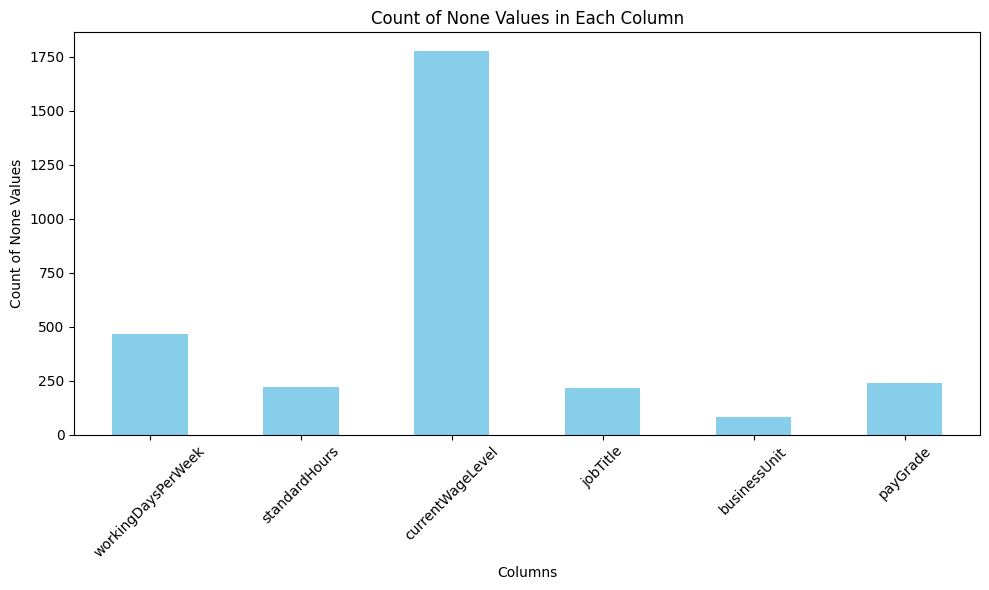

In [ ]:
import matplotlib.pyplot as plt


# Count the number of None values in each column
none_counts = df_filtered.isna().sum()

# Display the result
print(none_counts)

# Visualize the None counts
plt.figure(figsize=(10, 6))
none_counts.plot(kind='bar', color='skyblue')
plt.title('Count of None Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Count of None Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered.shape

(1774, 6)

In [ ]:
# Drop the 'currentWageLevel' column
df_filtered_dropped = df_filtered.drop(columns=['currentWageLevel'])

# Display the resulting dataframe
print(df_filtered_dropped.head())

   workingDaysPerWeek  standardHours                       jobTitle  \
0                 6.0           40.0      Capacity Planning Manager   
1                 NaN           40.0      Customer Service Agent 10   
2                 3.0           20.0  Planning & Scheduling Manager   
3                 7.0           35.0            Engineering Manager   
4                 5.0           40.0            Executive Assistant   

  businessUnit payGrade  
0        PRODS    GR-08  
1         CORP    GR-10  
2        PRODS    GR-08  
3        PRODS    GR-10  
4         CORP    GR-03  


In [ ]:
# Take a sample of 1000 lines
df_sample = df_filtered_dropped.sample(n=400, random_state=1)

In [ ]:
df_sample.shape

(400, 5)

In [ ]:
from openai import OpenAI
import os

os.environ['OPENAI_API_KEY'] = 'YOUR OPENAI KEY'

client = OpenAI( api_key=os.environ['OPENAI_API_KEY'])

# Convert the DataFrame to CSV format string
data_with_anomaly = df_sample.to_csv(index=False)

# Step 2: Determine the messages to send to the model
messages = [
	{
      "role": "system",
      "content": """You are a data analyser which spots any anomaly
										in the data received. You will be given data in the form
										of a CSV. There can be no anomaly but there can also be
										multiple anomalies. Let’s think step by step. First work out
										the schema of the data you receive. Then compare the data you
										have to the schema you determined. Don't decide what is an
										anomaly until you have figured out the schema.""",
  },
	{
      "role": "user",
      "content": "Here is the data to analyse, what are the anomalies? Please give me the line number with the anomaly. Make sure to remember on which line of the CSV the anomaly was (ignore the first line since these are the column titles): "
      + data_with_anomaly,
  },
]

# Step 3: Get the response from the model
response = client.chat.completions.create(
      model= "gpt-4" , # Add the model you would like to use, e.g. gpt-3.5-turbo-1106 or gpt-4-1106-preview
      messages=messages,
      max_tokens=1000,
  )

# Step 4: Show the anomaly
print(response.choices[0].message.content)

Based on the given CSV data, the schema appears to be as follows:

- workingDaysPerWeek: Numeric (mostly 5.0, but there are some other values as well). This field can be empty.
- standardHours: Numeric (mostly 40.0). This field can be empty.
- jobTitle: String (a variety of job positions including international characters). This field can be empty.
- businessUnit: String (mostly 'CORP', 'PRODS', 'SALES', 'GCS', 'ECO', and 'RETAIL'). This field can be empty.
- payGrade: String (mostly something like 'GR-XX' or 'H-XX'). This field can be empty.

The anomalies in the data are entries that deviate from this schema. Here are the anomalies discovered in terms of line number (ignoring the first line):

- Line 3: All fields are empty.
- Line 9: The "workingDaysPerWeek" field is empty.
- Line 11: The "workingDaysPerWeek" field is empty.
- Line 12: The "workingDaysPerWeek" field is empty.
- Line 14: The "jobTitle", "businessUnit" and "payGrade" fields are empty.
- Line 18: The "workingDaysPerWee

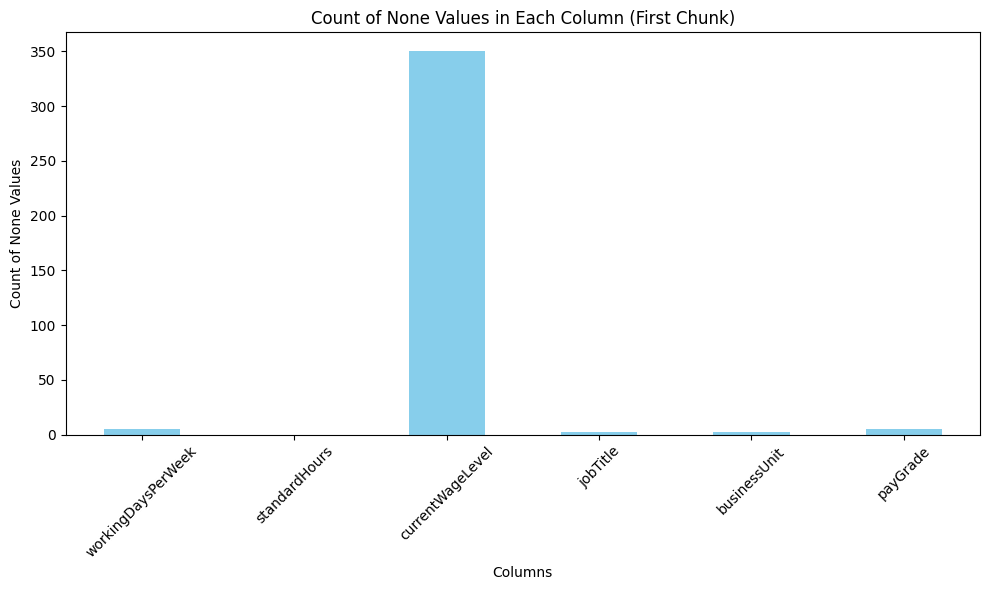

Filtered data without 'currentWageLevel' saved to filtered_jobinfo_chunk_1.csv
Filtered data without 'currentWageLevel' saved to filtered_jobinfo_chunk_2.csv
Filtered data without 'currentWageLevel' saved to filtered_jobinfo_chunk_3.csv
Filtered data without 'currentWageLevel' saved to filtered_jobinfo_chunk_4.csv
Filtered data without 'currentWageLevel' saved to filtered_jobinfo_chunk_5.csv
Filtered data without 'currentWageLevel' saved to filtered_jobinfo_chunk_6.csv
Checking anomalies for chunk 1...
Anomalies for chunk 1 saved to anomalies_chunk_1.txt
Checking anomalies for chunk 2...
Anomalies for chunk 2 saved to anomalies_chunk_2.txt
Checking anomalies for chunk 3...
Anomalies for chunk 3 saved to anomalies_chunk_3.txt
Checking anomalies for chunk 4...
Anomalies for chunk 4 saved to anomalies_chunk_4.txt
Checking anomalies for chunk 5...
Anomalies for chunk 5 saved to anomalies_chunk_5.txt
Checking anomalies for chunk 6...
Anomalies for chunk 6 saved to anomalies_chunk_6.txt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
import os
import math

# Load the CSV file
file_path = '/content/jobinfo.csv'
df = pd.read_csv(file_path)

# Define the number of rows per chunk
chunk_size = 350

# Calculate the number of chunks
num_chunks = math.ceil(len(df) / chunk_size)

# Define the columns to keep
columns_to_keep = [
    'workingDaysPerWeek', 'standardHours', 'currentWageLevel',
    'jobTitle', 'businessUnit', 'payGrade'
]

# Create a list to hold the DataFrames for each chunk
df_chunks = []

# Split the DataFrame into chunks and filter columns
for i in range(num_chunks):
    start_row = i * chunk_size
    end_row = start_row + chunk_size
    df_chunk = df.iloc[start_row:end_row][columns_to_keep]
    df_chunks.append(df_chunk)

# Visualize the number of None values in each column for the first chunk as an example
none_counts = df_chunks[0].isna().sum()
plt.figure(figsize=(10, 6))
none_counts.plot(kind='bar', color='skyblue')
plt.title('Count of None Values in Each Column (First Chunk)')
plt.xlabel('Columns')
plt.ylabel('Count of None Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Drop the 'currentWageLevel' column in each chunk
df_chunks_dropped = [chunk.drop(columns=['currentWageLevel']) for chunk in df_chunks]

# Save each chunk to a new CSV file and convert to CSV format string
csv_strings = []
for i, chunk in enumerate(df_chunks_dropped):
    output_path = f'filtered_jobinfo_chunk_{i + 1}.csv'
    chunk.to_csv(output_path, index=False)
    csv_strings.append(chunk.to_csv(index=False))
    print(f"Filtered data without 'currentWageLevel' saved to {output_path}")

# OpenAI API key
os.environ['OPENAI_API_KEY'] = 'OPENAI_API_KEY'
client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

# Function to check each chunk for anomalies
def check_anomalies(data_chunk, chunk_index):
    messages = [
        {
            "role": "system",
            "content": """You are a data analyser which spots any anomaly
                          in the data received. You will be given data in the form
                          of a CSV. There can be no anomaly but there can also be
                          multiple anomalies. Let’s think step by step. First work out
                          the schema of the data you receive. Then compare the data you
                          have to the schema you determined. Don't decide what is an
                          anomaly until you have figured out the schema.""",
        },
        {
            "role": "user",
            "content": "Here is the data to analyse, what are the anomalies? Please give me the line number with the anomaly. Make sure to remember on which line of the CSV the anomaly was (ignore the first line since these are the column titles): \n\n" + data_chunk,
        },
    ]

    response = client.chat.completions.create(
        model="gpt-4",  # Add the model you would like to use, e.g. gpt-3.5-turbo-1106 or gpt-4-1106-preview
        messages=messages,
        max_tokens=1000,
    )

    # Save the response to a text file
    output_path_txt = f'anomalies_chunk_{chunk_index + 1}.txt'
    with open(output_path_txt, 'w') as file:
        file.write(response.choices[0].message.content)
    print(f"Anomalies for chunk {chunk_index + 1} saved to {output_path_txt}")

# Check anomalies for each chunk
for i, csv_string in enumerate(csv_strings):
    print(f"Checking anomalies for chunk {i + 1}...")
    check_anomalies(csv_string, i)
